Data Project.

Question 1.1

In [3]:
#The importing of the necessary libraries and setup for the API
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

#API
%pip install git+https://github.com/alemartinello/dstapi
from dstapi import DstApi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/pip-req-build-6oqkcmnd
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/pip-req-build-6oqkcmnd
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


1.1 The Gini coefficient and the top 10 percent share

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


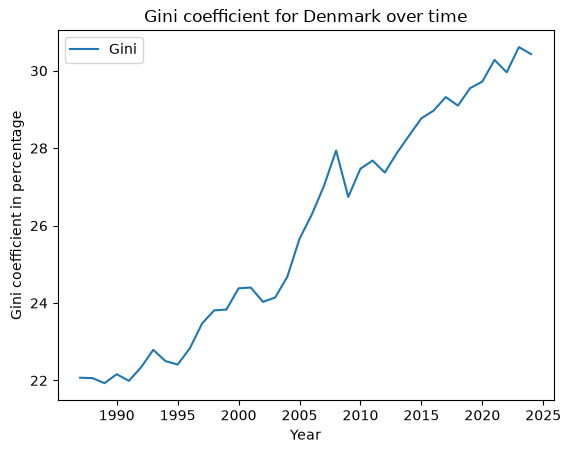

Figure shows an overall increase in Gini over time, in the given period.
Smaller fluctuations are found around mid 1990s and mid 2000s, but the overall trend is an increase in Gini coefficient, which indicates a growing inequality in Denmark over time.


In [4]:
#importing the data from DST for IFOR41
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')

#download parameters for IFOR41 data
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']},
    ]
}
Gini = IFOR41.get_data(params=params)


#Converting the years into integers and the Gini coefficient into floats
Gini['TID'] = Gini['TID'].astype(int)
Gini['INDHOLD'] = Gini['INDHOLD'].astype(float)

#Dropping the unnecessary columns and renaming 
Gini = Gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

Gini = Gini.rename(columns={
    'INDHOLD': 'Gini',
    'TID': 'year'
})

#Sorting the data by year and making it the index
Gini = Gini.set_index('year').sort_index()

#Figure for the Gini coefficient over time in Denmark
Gini.plot()

plt.xlabel('Year')
plt.ylabel('Gini coefficient in percentage')
plt.title('Gini coefficient for Denmark over time')
plt.show()

print('Figure shows an overall increase in Gini over time, in the given period.')
print('Smaller fluctuations are found around mid 1990s and mid 2000s, but the overall trend is an increase in Gini coefficient, which indicates a growing inequality in Denmark over time.')


1.1 (Continued) The development in share of income held by the top 10% of the population + correlation with Gini development

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/ipykernel_27530/593870773.py:36: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  Income['DECILGEN'] = pd.Categorical(


,DECILGEN,KOMMUNEDK,TID,INDHOLD
260,First decil,All Denmark,1987,31418
261,Second decil,All Denmark,1987,59014
262,Third decil,All Denmark,1987,68786
263,Fourth decil,All Denmark,1987,77577
264,Fifth decil,All Denmark,1987,85361
...,...,...,...,...
206,Sixth decil,All Denmark,2024,311118
207,Seventh decil,All Denmark,2024,348230
209,Ninth decil,All Denmark,2024,466658
201,Tenth decil,All Denmark,2024,852980


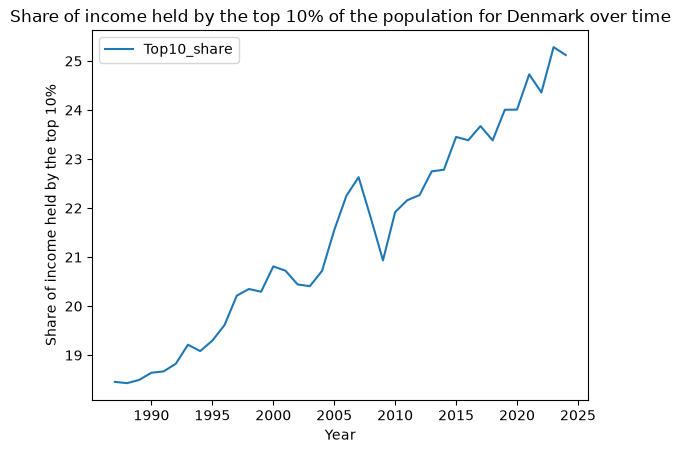

Just as the Gini coeff. the share of top10 income has likewise increased over time, in the same period in Denmark.
This can indicate an increasing inequality in Denmark, just as the Gini coeff. does.


In [5]:
#importing the data from DST IFOR32
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

#download parameters and setup/sorting for IFOR32
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']},
    ]
}

#Defining income
Income = IFOR32.get_data(params=params)


#Converting years into intergers and sorting by year and decile
Income['TID'] = Income['TID'].astype(int)
decile_order = [
    'First decil',
    'Second decil',
    'Third decil',
    'Fourth decil',
    'Fifth decil',
    'Sixth decil',
    'Seventh decil',
    'Eighth decil',
    'Ninth decil',
    'Tenth decil'
]

Income['DECILGEN'] = pd.Categorical(
    Income['DECILGEN'],
    categories=decile_order,
    ordered=True
)
Income = Income.sort_values(['TID', 'DECILGEN'])

#Checking the data, if the ordering came out right
display(Income)

#Calculating the share of income held by the top 10% of the population for each year
#The formula used is: (income of top 10% / total income)
Top10 = (
    Income.groupby('TID')
    .apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0]
           / x['INDHOLD'].sum()
    * 100)
    .reset_index(name='Top10_share')
)

Top10 = Top10.rename(columns={'TID': 'year'})

Top10.plot(x='year', y='Top10_share')

plt.title('Share of income held by the top 10% of the population for Denmark over time')
plt.xlabel('Year')
plt.ylabel('Share of income held by the top 10%')
plt.show()

print('Just as the Gini coeff. the share of top10 income has likewise increased over time, in the same period in Denmark.')
print('This can indicate an increasing inequality in Denmark, just as the Gini coeff. does.')

0.981641545052772


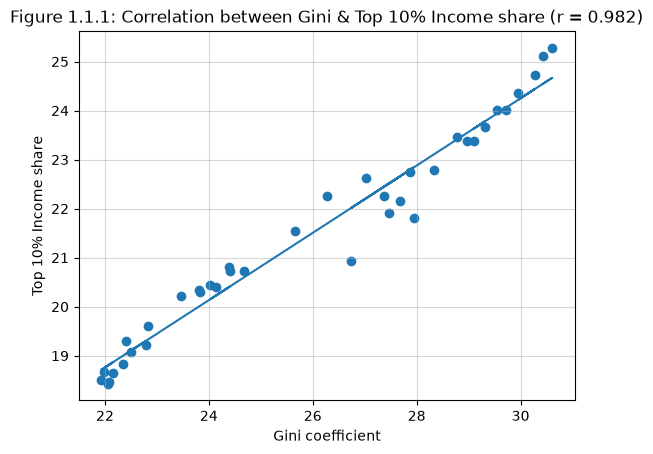

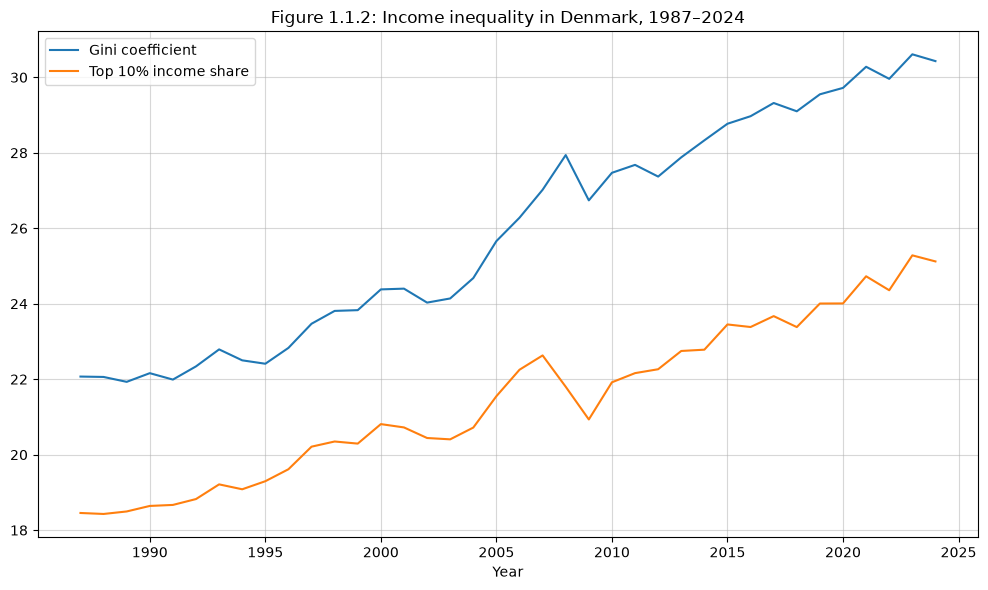

The figures shows a strong positive correlated between the two measures of inequality, given the r value of 0.982.


In [21]:
#Correlation between Gini and top 10% income share, plotting the results
GiniTop10 = pd.merge(
    Gini.reset_index(),
    Top10,
    on='year',
    validate='1:1'
)
GiniTop10 = GiniTop10.set_index('year').sort_index()

corr = GiniTop10['Gini'].corr(GiniTop10['Top10_share'])
print(corr)

#Find trendline + scatter plot + plotting the results

x = GiniTop10['Gini']
y = GiniTop10['Top10_share']  # Convert to percentage

slope, intercept = np.polyfit(x, y, 1)


plt.scatter(x, y)

plt.plot(x, slope * x + intercept)

plt.xlabel('Gini coefficient')
plt.ylabel('Top 10% Income share')
plt.title(f'Figure 1.1.1: Correlation between Gini & Top 10% Income share (r = {corr:.3f})')
plt.grid(alpha=0.5)

plt.show()

#Correlation OVER TIME

plt.figure(figsize=(10, 6))

plt.plot(GiniTop10.index, GiniTop10['Gini'], label='Gini coefficient')
plt.plot(GiniTop10.index, GiniTop10['Top10_share'],label='Top 10% income share')

plt.xlabel('Year')
plt.title('Figure 1.1.2: Income inequality in Denmark, 1987–2024')
plt.legend()
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

print('The figures shows a strong positive correlated between the two measures of inequality, given the r value of 0.982.') 



Question 1.2: The linear trend

Linear trend values for a and b: [ 0.2635496  21.04275353]
Linear Numpy polyfit trend: [ 0.26354962 21.04275304]
Predicted Gini in 2030 (linear trend): 32.375
Predicted Gini in 2040 (linear trend): 35.011


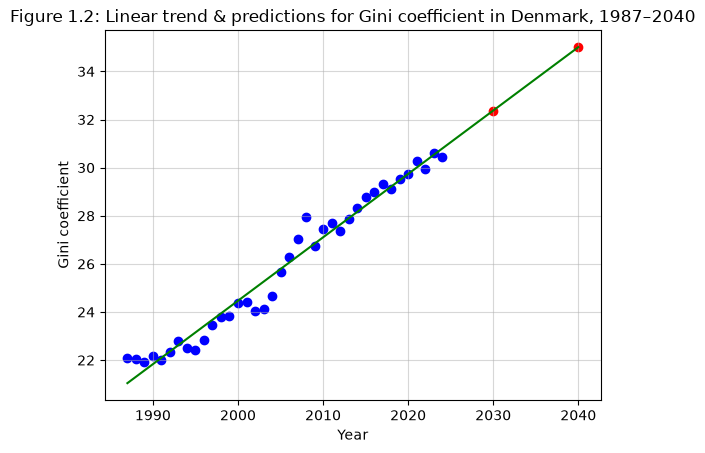

In [7]:
#Importing, mathplotlib and numpy alreeady imported
from scipy.optimize import minimize

#Fitting a linear and quadratic trend to the Gini to predict inequality in Denmark in 2030 and 2040
#We start by defining time as a variable, where 0 corresponds to the year 1987, 1 to 1988, and so on.

Gini['t'] = Gini.index - 1987

t = Gini['t'].values
y = Gini['Gini'].values

#Now defining the the function we want to minimize and minimizing it for linear

def linear_tr(params):                 #Definig the function to minimize
    a, b = params                      #Function inputs
    y_pred = a * t + b                 #Predicted values of y based on the linear model
    return np.sum((y - y_pred) ** 2)   #Squared error between the actual and predicted values

linear_gini_trend = minimize(linear_tr, x0=[0, 0])  #Minimizing the function with initial guess of [0, 0], does not matter what the initial guess is, the function needs an initial guess.
print('Linear trend values for a and b:', linear_gini_trend.x)

#We check if the coefficient are the same as Numpy's polyfit function values:

np_linear_trend = np.polyfit(t, y, 1) #We know it is linear by the setting of degrees = 1 (last argument)

print('Linear Numpy polyfit trend:', np_linear_trend)
a_polyfit, b_polyfit = np.polyfit(t, y, 1)

#We can tell that the values are roughly the same.
#After checking we now compute the predicted Gini for 2030 and 2040 using the found values, and plotting.

a, b = linear_gini_trend.x #Defining a and b

gini_2030_linear = a * (2030 - 1987) + b
gini_2040_linear = a * (2040 - 1987) + b

print(f"Predicted Gini in 2030 (linear trend): {gini_2030_linear:.3f}")
print(f"Predicted Gini in 2040 (linear trend): {gini_2040_linear:.3f}")

#For plotting we start by defining the years we want to plot, including predictions
years_linear = np.arange(1987, 2041)

t_years = years_linear - 1987 #Convert to t

gini_linear = a * t_years + b  #The linearly predicted Gini using the wanted range of years 

plt.scatter(Gini.index, Gini['Gini'], label='Gini', color='blue')                     #Scatter for Gini
plt.plot(years_linear, gini_linear, label='Linear trend', color='green')              #Plotting the linear trend
plt.scatter([2030, 2040], [gini_2030_linear, gini_2040_linear], color='red', label='Predictions')   #The two predictions

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.title('Figure 1.2: Linear trend & predictions for Gini coefficient in Denmark, 1987–2040')
plt.grid(alpha=0.5)

1.2 (continued): The quadratic trend

Quadratic trend values for a, b, and c: [1.17765521e-03 2.19976505e-01 2.13041842e+01]
Quadratic Numpy polyfit trend: [1.17769085e-03 2.19975061e-01 2.13042004e+01]
Predicted Gini 2030 (quadratic trend): 32.941
Predicted Gini 2040 (quadratic trend): 36.271


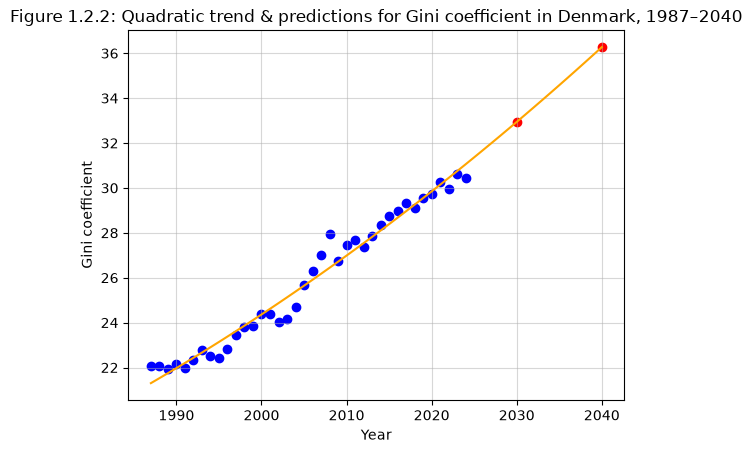

In [8]:
#Now looking at the quadratic trend, we define the function to minimize and minimize it:

def quad_tr(params):                          #Defining quadratic function
    a, b, c = params                         #Function inputs
    y_pred = a * t**2 + b * t + c            #Predicted values of y based on the quadratic model
    return np.sum((y - y_pred) ** 2)         #Squared error between the actual and predicted values

quad_gini_trend = minimize(quad_tr, x0=[0, 0, 0])       #Minimizing the function with initial guess of [0, 0, 0]
print('Quadratic trend values for a, b, and c:', quad_gini_trend.x)

#Now for Numpy's polyfit function, we set the degree to 2 for quadratic:
np_quad_trend = np.polyfit(t, y, 2)
print('Quadratic Numpy polyfit trend:', np_quad_trend)

#The values are again roughly the same.
#Now we compute the predicted Gini with our calculated values.

a_quad, b_quad, c_quad = quad_gini_trend.x      #Defining a, b and c
y_quad_pred = a_quad * t_years**2 + b_quad * t_years + c_quad  #Quad function

gini_2030_quad = a_quad * (2030 - 1987)**2 + b_quad * (2030 - 1987) + c_quad
gini_2040_quad = a_quad * (2040 - 1987)**2 + b_quad * (2040 - 1987) + c_quad

print(f"Predicted Gini 2030 (quadratic trend): {gini_2030_quad:.3f}")
print(f"Predicted Gini 2040 (quadratic trend): {gini_2040_quad:.3f}")

#Plotting
years_quad = np.arange(1987, 2041)  #Years for plotting
t_years_quad = years_quad - 1987    #Convert to t

plt.scatter(Gini.index, Gini['Gini'], label='Gini', color='blue')                     #Scatter for Gini
plt.plot(years_quad, a_quad * t_years_quad**2 + b_quad * t_years_quad + c_quad, label='Quadratic trend', color='orange')  #
plt.scatter([2030, 2040], [gini_2030_quad, gini_2040_quad], color='red', label='Predictions')   #The two predictions

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.title('Figure 1.2.2: Quadratic trend & predictions for Gini coefficient in Denmark, 1987–2040')
plt.grid(alpha=0.5)



The outputs for both specifications are similar for year 2030, for linear around 32.375 and quadratic around 32.941, meaning their prediction are not far from each other. 
For 2040 they differ more, for the linear specification it is 35.011 and for the quadratic it is 36.271. This indicates that a prediction further into the future might differ even more between the two specifications.
Trusting such simple forecast can be hard, as both specifications are based on simple functions only considering short-term historic data of past Gini observations. For a more trustwothy prediction, we would need to construct a more extensive econometric model which would include other economic and demographic measures which contribute to the development in inequality measures like Gini. 

Question 1.3: Municipalities

1.3.1:

In [13]:
#Correlated between Gini coeff. and top10 share across municipalities in Denmark, is it similar as before?
#Download IFOR41
#download parameters for IFOR41 data
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']},
    ]
}
Gini_mun = IFOR41.get_data(params=params)


#Converting the years into integers and the Gini coefficient into floats
Gini_mun['TID'] = Gini_mun['TID'].astype(int)
Gini_mun['INDHOLD'] = Gini_mun['INDHOLD'].astype(float)

#Dropping the unnecessary columns and renaming 
Gini_mun = Gini_mun.drop(columns='ULLIG')

Gini_mun = Gini_mun.rename(columns={
    'INDHOLD': 'Gini',
    'TID': 'year'
})

Gini_mun = Gini_mun.sort_values(['KOMMUNEDK', 'year'])

#download parameters and setup/sorting for IFOR32
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']},
    ]
}

Income_mun = IFOR32.get_data(params=params)

Top10_mun = (
    Income_mun
    .groupby(['KOMMUNEDK', 'TID'])
    .apply(
        lambda x:
        x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0]
        / x['INDHOLD'].sum()
        * 100)
    .reset_index(name='Top10_mun')
)

Top10_mun = Top10_mun.rename(columns={'TID': 'year'})

#display(Top10_mun)
#display(Gini_mun)

#Merging the two data sets:
GiniTop10_mun = pd.merge(
    Gini_mun,
    Top10_mun,
    on=['KOMMUNEDK', 'year'],
    validate='1:1'
)

corr_mun = GiniTop10_mun['Gini'].corr(
    GiniTop10_mun['Top10_mun']
)

print('Correlation between Top10 and Gini across municipalities:', corr_mun)
print('Correlation between the two measure is a big lower, but still very high.')
print('Last corr was around 0.9816 and the new one is 0.9605.')

Correlation between Top10 and Gini across municipalities: 0.9605447380548026
Correlation between the two measure is a big lower, but still very high.
Last corr was around 0.9816 and the new one is 0.9605.


1.3.2:

10 most unequal municipalities:


,KOMMUNEDK,year,Gini
3471,Gentofte,2024,49.04
3489,Rudersdal,2024,47.31
3529,Vejen,2024,46.32
3488,Hørsholm,2024,40.07
3478,Lyngby-Taarbæk,2024,39.28
3467,Frederiksberg,2024,36.54
3466,Copenhagen,2024,34.97
3547,Aarhus,2024,33.43
3485,Fredensborg,2024,32.76
3486,Helsingør,2024,30.55


10 least unequal municipalities:


,KOMMUNEDK,year,Gini
3542,Odder,2024,24.70
3475,Albertslund,2024,24.66
3550,Hedensted,2024,24.58
3513,Assens,2024,24.46
3494,Halsnæs,2024,24.41
3541,Favrskov,2024,24.41
3500,Faxe,2024,24.09
3511,Bornholm,2024,24.03
3490,Egedal,2024,23.85
3514,Faaborg-Midtfyn,2024,23.77


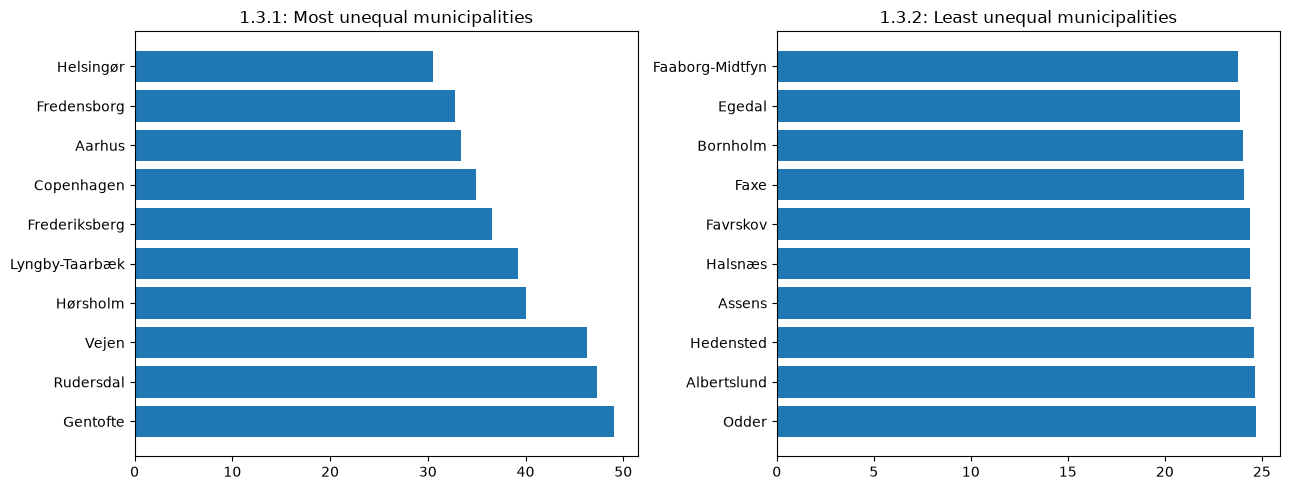

The most unequal municipalities seem to vary more than the least equal municipalities.


In [ ]:
#Top 10 most and bottom 10 municipalities in unequality in Denmark

Gini_mun_2024 = Gini_mun[Gini_mun['year'] == 2024]  #The most recent year in the data set


most_unequal = (
    Gini_mun_2024
    .sort_values('Gini', ascending=False)
    .head(10)
)

least_unequal = (
    Gini_mun_2024
    .sort_values('Gini', ascending=False)
    .tail(10)
)

print('10 most unequal municipalities:')
display(most_unequal)

print('10 least unequal municipalities:')
display(least_unequal)

#Plotting it
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(most_unequal['KOMMUNEDK'], most_unequal['Gini'])
axes[0].set_title('1.3.1: Most unequal municipalities')


axes[1].barh(least_unequal['KOMMUNEDK'], least_unequal['Gini'])
axes[1].set_title('1.3.2: Least unequal municipalities')


plt.tight_layout()
plt.show()
print('The most unequal municipalities seem to vary more than the least equal municipalities.')


1.3.3:

Largest change in Gini across municipalities, 1987-2024
                Gini_1987  Gini_2024  Gini_change
KOMMUNEDK                                        
Vejen               21.20      46.32        25.12
Rudersdal           29.05      47.31        18.26
Gentofte            31.10      49.04        17.94
Lyngby-Taarbæk      24.97      39.28        14.31
Copenhagen          23.05      34.97        11.92
Smallest change in Gini across municipalities, 1987-2024
           Gini_1987  Gini_2024  Gini_change
KOMMUNEDK                                   
Fanø           25.67      26.34         0.67
Ærø            24.63      26.98         2.35
Faxe           21.64      24.09         2.45
Læsø           22.81      25.41         2.60
Bornholm       21.31      24.03         2.72


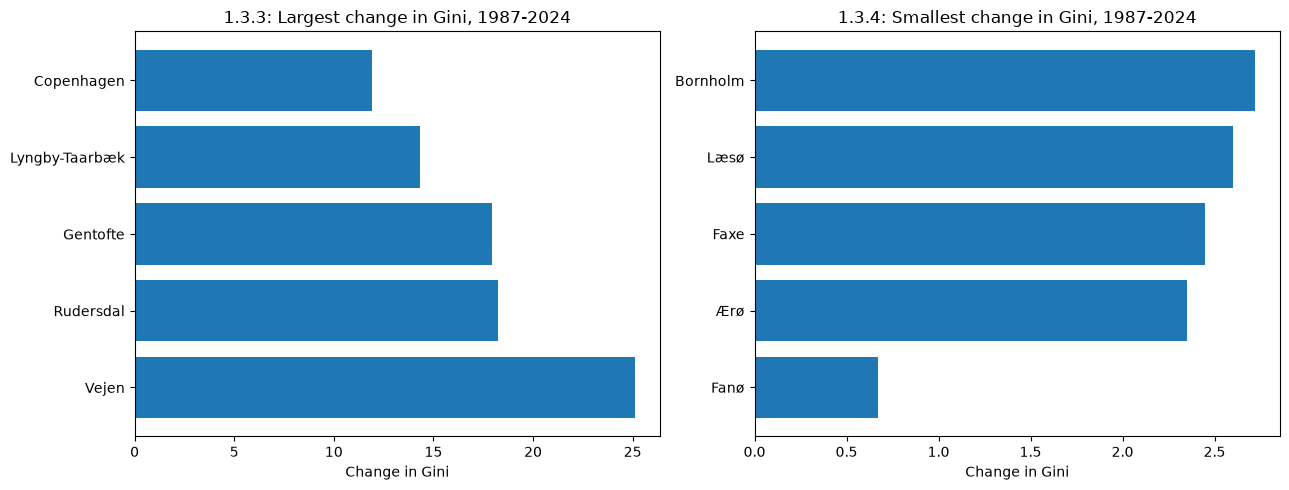

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [ ]:
#Municipalities with largest and smallest change in Gini over the years.
Gini_mun = Gini_mun.sort_values(['KOMMUNEDK', 'year'])

change = (
    Gini_mun
    .groupby('KOMMUNEDK')
    .agg(
        Gini_1987=('Gini', 'first'),
        Gini_2024=('Gini','last')
    )
)

change['Gini_change'] = change['Gini_2024'] - change['Gini_1987']

largest_change = change.sort_values('Gini_change', ascending=False).head(5)
smallest_change = change.sort_values('Gini_change').head(5)

print('Largest change in Gini across municipalities, 1987-2024')
print(largest_change)


print('Smallest change in Gini across municipalities, 1987-2024')
print(smallest_change)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(largest_change.index, largest_change['Gini_change'])
axes[0].set_title('1.3.3: Largest change in Gini, 1987-2024')
axes[0].set_xlabel('Change in Gini')

axes[1].barh(smallest_change.index, smallest_change['Gini_change'])
axes[1].set_title('1.3.4: Smallest change in Gini, 1987-2024')
axes[1].set_xlabel('Change in Gini')

plt.tight_layout()
plt.show()

Comparing with the figures from previous part of the question, we can tell that the municipalities which had the most change in Gini coeff. are also the same which currently have the highest unequality.
Same goes for the lowest change and unequality. 

1.4: